# **Lab 02: Dataset manipulation and visualization**

Welcome to lab 2. This week you'll do some command line crash coursing and learn how to use Pandas and Matplotlib to filter and visualize a dataset. Below is a more explicit recap and preview.

**RECAP.** Last week, you:
- gained experience creating a virtual programming environment (geol415) for your lab work this semester.
- opened a Jupyter notebook, selected the proper **kernel** to run your code with, and executed a line of code to ensure that you were using the Python version you installed in the (geol415) environment.

**PREVIEW.** This week, you will:
- gain some more experience with terminal commands.
- learn to download and properly import tabular data from the internet.
- filter, subset, and visualize data from said dataset.

# **0.** Make sure everything is in it's right place.

To start this lab properly, you'll need to do the following:
1. Activate **the correct** virtual programming environment.
2. Launch a jupyter notebook session.
3. Find the notebook (lab02.ipynb) for this lab.

**Step 1:** This can be done in 2 ways, either via **Anaconda Navigator** or your **command line**. If you want to use the handy visual interface of the Anaconda Navigator, then open it up, click on "Environments" on the left side of the screen. Find "geol415". From there, you can either launch a terminal session using that environment, or click "Open with Jupyter notebook" to shortcut to step 2. Now, if you want to use your terminal, open a terminal **(Anaconda prompt for Windows users)** window and type in the following text.

In [ ]:
# MacOS/linux command
conda activate geol415
jupyter notebook
# Windows (from Anaconda prompt!!!)
conda activate geol415
jupyter notebook
# note: these are the same and should both work. Let me know if they do not.

**Step 2:** For those using Anaconda Navigator, click your environment and select "Open with Jupyter notebook". This will take you to a jupyter session from (presumably) your home/user directory. 

**Step 3:** You should now see your computer's files from within your jupyter session. Navigate to wherever you have stored your **lab02.ipynb** and click to open. Please make sure you are using the proper kernel (the one that says GEOL415 in the name).

# **1.** **[SKIP UNTIL END FOR TIME]** Back to the command line (within a Jupyter Notebook! What??) 

Here we'll run through some basic commands you can run in your terminal. The hack here is that you can run shell commands from a jupyter notebook as long as you put an "!" at the beginning of a block of python code. Below is an example

In [ ]:
# this command, pwd, prints the current directory you are in (i.e. folder).
!pwd

In [ ]:
# windows version. This should display the same thing
!cd

## 1a. List all files in current directory

In [ ]:
# macOS/linux basic command
!ls
# this will show more metadata associated with the files, and show hidden files as well.
!ls -la 

In [ ]:
# windows 
!dir 
# windows to show hidden files
!dir /a

## 1b. Change directory to a different one.

There are two ways to navigate through your file system -- down the tree to different subdirectory, or up tree to a higher parent directory.

First, navigate to your home directory

In [ ]:
# macOS
!cd ~/

In [ ]:
# windows
!cd ~ #OR
# if above doesn't work.
# replace %userprofile% with your actual user prof name!!
!cd /d %userprofile%  

Now, let's see what files are in the current directory. Let's pick one to navigate to, e.g. your Desktop folder.

In [ ]:
#Mac 
!ls -al

In [ ]:
# Windows
!dir /a

Navigate to Desktop now. THEN, change directory into a folder of your choice.

In [ ]:
# MacOS and Windows 
!cd Desktop
!cd replace_with_folder_in_Desktop

Now, let's backtrack back to Desktop. To reverse the directory change, we can run the following.

In [ ]:
!pwd #OR !dir if Windows. Ensures we're in Desktop/subdirectory_of_desktop
!cd .. # double dots means go up one.

Let's get back to home.

In [ ]:
!pwd # OR !dir. Should say Desktop
!cd ..

Hopefully this will help you navigate your computer's file systems from a text-based standpoint. There are a lot more commands to be learned that will increase the utility of text-based file management. I'm happy to include more in future labs if intereste. The best way to get more comfortable with this is to try this out in your day to day usage of your computer. 

### **NOW**, let's move on to what we've all been wanting to do since week 1: Data science!

# 2. Let's do something with data.

We'll be using a record of atmospheric CO2 concentration (units: parts per million, ppm) derived from ice cores as our first example of data analysis in this course. The goal of this section is to filter and plot some data, and learn the basics of **pandas** and **matplotlib** in doing so.

The ice core data comes from this larger dataset: Rubino et al., (2019): *Law Dome Ice Core 2000-Year CO2, CH4, N2O and d13C-CO2. v1. CSIRO. Data Collection*. https://doi.org/10.25919/5bfe29ff807fb


## 2a. Import necessary programming packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# don't worry about this next line
%matplotlib inline

This is a common way to import all elements of a progamming package. The above abbreviations are very commonly used for these libraries. 

There are other ways to import **specific** things from libraries where you don't need everything else. For example, let's say we want to import JUST the mean function from numpy. Below is how you'd do it.

In [3]:
from numpy import mean

Now, you can call mean() without having to write "np.mean(...)" every time. Try running the cell below.

In [4]:
list_of_numbers = [1,2,3,4,5]
mean(list_of_numbers)

3.0

# 2b. Make sure you've downloaded the data file **and extracted it from the .zip file**.

THEN, get the path to the file named **"Law_Dome_CO2_2000years.csv"**. This is a file whose data are comma-separated (i.e. comma-separated values, or csv!). If you are coding in a jupyter notebook that is in the SAME place the data are stored, you don't need to do anything special. However, if it's loaded anywhere else, **I'd recommend grabbing the absolute path to the data file.**

**TIPS FOR GETTING FILEPATH NAME**: 

MacOS: make sure file is highlighted in blue in your Finder (i.e. click on it once). Then click Option + Command + C. Then paste into the "data_path" var name below.

Windows: Same as above, but Ctrl + Shift + C. Paste below.

In [5]:
# assign pathname to variable data_path.
#macOS example
# data_path = '/Users/dgetter/Data/GEOL415/lab02/Law_Dome_CO2_2000years.csv'
data_path = 'Law_Dome_CO2_2000years.csv'
#windows example
# data_path = 'C:\Users\dgetter\Data\GEOL415\lab02\Law_Dome_CO2_2000years.csv'

## 2c. Pandas practice
Pandas is a powerful tool many data scientists use in performing data analysis. Any time you see Python code dedicated to analyzing data, chances are they do so using pandas. It's therefore important to get some experience using pandas to manipulate data ourselves. In 2a, we imported pandas with the common abbreviation "pd".

#### **Problem 1:** Load data using the **read_csv()** function.

This function reads in any dataset stored in .csv format. It takes the data path as the main argument (argument = anything you put in a function parentheses). Remember, if you imported pandas as pd, you need to write pd.function() to call function. See below

In [6]:
df = pd.read_csv(data_path) # replace "___" with proper function.
print(type(df)) # verifies data type we want.
df.head() # the .head() method shows first 5 rows of data.

<class 'pandas.core.frame.DataFrame'>


,Sample ID,Ice Age (year AD),CO2 Age (year AD),CO2 (ppm),Uncert (ppm)
0,DSSW20K 15.8,firn,1996.28,359.866667,0.015275
1,DSSW20K 29,firn,1994.41,357.240000,0.037417
2,DE08-2 0,firn,1993.08,354.565000,0.021213
3,DSSW20K 37.8,firn,1992.31,353.885000,0.038730
4,DE08-2 10,firn,1991.13,352.610000,0.183848


This is a specific data structure within pandas called a DataFrame. It's 2-D, and has rows and columns that can be easily manipulated and filtered using pandas functions. Let's go through some basics to get to know our data.

#### **Problem 2:** Find a function that can **describe** the broader statistics of the dataset. 

This function is a property of the dataset itself. I.e. do not call pd.function_that_describes(df), but rather df.function_that_describes(). 

HINT: you need a function to **describe()** the data....

In [7]:
df.describe()

,CO2 Age (year AD),CO2 (ppm),Uncert (ppm)
count,321.000000,321.000000,321.000000
mean,1726.291277,299.014962,1.122478
std,417.595880,19.407794,0.962726
min,153.530000,271.247000,0.000000
25%,1773.460000,282.309000,0.582000
50%,1899.000000,295.270000,0.770000
75%,1944.910000,311.871000,1.256000
max,1996.280000,359.866667,6.437000


#### **Problem 3:** Let's subset this DataFrame to isolate columns we care about.

Let's go back and look at the first few rows:

In [8]:
df.head()

,Sample ID,Ice Age (year AD),CO2 Age (year AD),CO2 (ppm),Uncert (ppm)
0,DSSW20K 15.8,firn,1996.28,359.866667,0.015275
1,DSSW20K 29,firn,1994.41,357.240000,0.037417
2,DE08-2 0,firn,1993.08,354.565000,0.021213
3,DSSW20K 37.8,firn,1992.31,353.885000,0.038730
4,DE08-2 10,firn,1991.13,352.610000,0.183848


Let's ignore some columns that we don't need right now. Specifically, let's remove the sample ID and ice age year columns to make our lives easier.

There are a few ways we can do this. First, we can reference columns by their specific names, for example, and just take the ones we want. Let's try and just isolate the CO2 measurements for starters.

In [9]:
# this isolates a single column (here, CO2 concentration)
df_co2 = df['CO2 (ppm)']
df_co2.head()

0    359.866667
1    357.240000
2    354.565000
3    353.885000
4    352.610000
Name: CO2 (ppm), dtype: float64

We treat the DataFrame as a dictionary, where the **keys** are column names, which point to **values**, which are the data we want. What this means is we take the DataFrame "df", and index into it by column name ("CO2 (ppm)") within square brackets ([]) after df.

We see here that individual DataFrame columns are actually Series objects. These are 1-D arrays that are nicely manipulatable. More on that later.

For now, though, the column names are a bit annoyingly written. **Let's rename some of them** so that we don't have to worry about case, spaces, or parentheses.

#### **Problem 3a.** Rename the **CO2 age, CO2 concentration**, and **uncertainty** columns in your pandas DataFrame by using the .rename() method associated with your df.



In [10]:
# first you need a dictionary mapping old --> new colnames
# replace '___' with actual, better names. Try making them all one lowercase word.
names_dict = {'CO2 Age (year AD)': 'age', 'CO2 (ppm)': 'conc', 'Uncert (ppm)': 'uncert'}

# then, pass this into .rename(). Make sure to REASSIGN your df to a new variable, typically of same name.
df = df.rename(columns = names_dict) # replace here
df.head() #verify

,Sample ID,Ice Age (year AD),age,conc,uncert
0,DSSW20K 15.8,firn,1996.28,359.866667,0.015275
1,DSSW20K 29,firn,1994.41,357.240000,0.037417
2,DE08-2 0,firn,1993.08,354.565000,0.021213
3,DSSW20K 37.8,firn,1992.31,353.885000,0.038730
4,DE08-2 10,firn,1991.13,352.610000,0.183848


Now, let's go back to our subsetting task. Retrieve the freshly renamed columns from the original df to form a subset thereof.

In [11]:
# This will retrieve YEAR, CO2 conc, and UNCERTAINTY from the df
columns_list = ['age','conc', 'uncert'] # input your newly named cols here
df_subset = df[columns_list]
df_subset.head()

,age,conc,uncert
0,1996.28,359.866667,0.015275
1,1994.41,357.240000,0.037417
2,1993.08,354.565000,0.021213
3,1992.31,353.885000,0.038730
4,1991.13,352.610000,0.183848


Here, we got the names of the columns we wanted, made the col names strings (with quotes), and created a list to subset the dataframe by. This is good and well, but for there are other, slightly cleaner ways to get here.

Pandas as a method of integer-based data indexing that will give us the same exact results. This is what **iloc**, or integer location, gives us. 

#### **Problem 4.** Use **iloc** to get the same columns as above.

iloc is a feature of pandas DataFrame objects. To use it, follow the format of DataFrame.iloc[rows_you_want, cols_you_want] (note SQUARE brackets). In our case, we want ALL rows of the data frame. The Pythonic way to denote this is with **":"**.

Remember, we want the last 3 columns of the dataframe. In Python, we start counting from 0. So, we want to start with the third column, which equals 2 in Python land. Then we want to get a slice of columns from 3 to the end. To indicate a range of values, we use **start_range_number:end_range_number+1**

In [30]:
# get three cols we care about
CO2_col_index = 2
end_index = 4
df_subset = df.iloc[:, 2:4+1] # replace with actual range here.
df_subset.head()

,age,conc,uncert
0,1996.28,359.866667,0.015275
1,1994.41,357.240000,0.037417
2,1993.08,354.565000,0.021213
3,1992.31,353.885000,0.038730
4,1991.13,352.610000,0.183848


Hooray! We get the same answer as before, without having to risk misspelling the column names. This method of subsetting a dataframe can be tricky at first, but you might find it becoming more intuitive over time.

Let's do some more exploring before we plot these data.

#### **Problem 5:** Comparing average CO2 values before and after 1750

We often need to subset data based on certain conditions. Let's see how to isolate CO2 values occurring in ice core data prior to and after 1750 (commonly used proxy for the start of industrialization). I will show you how do do this for the pre-1750 case. 

We can check which data points occur before 1750 with a **conditional expression** (i.e. >, <, <=, >=):

In [31]:
pre_1750 = df_subset['age'] < 1750 
print(pre_1750)

0      False
1      False
2      False
3      False
4      False
       ...  
316     True
317     True
318     True
319     True
320     True
Name: age, Length: 321, dtype: bool


This Series of True/False values can then be used to index the rest of the data frame to get values we care about. See below

In [32]:
pre_1750_df = df_subset[pre_1750]
pre_1750_df

,age,conc,uncert
246,1749.12,277.590,0.629
247,1746.00,275.368,0.467
248,1741.26,276.941,0.929
249,1733.99,278.443,0.929
250,1723.01,277.145,0.929
...,...,...,...
316,274.44,280.243,2.540
317,266.10,278.449,0.638
318,240.60,280.384,0.638
319,174.53,277.690,0.427


#### Problem **5a**. Do this but for years AFTER 1750.

In [34]:
post_1750 = df_subset['age'] > 1750 # change the "__" to a proper operator.
post_1750_df = df_subset[post_1750]
post_1750_df.head()

,age,conc,uncert
0,1996.28,359.866667,0.015275
1,1994.41,357.240000,0.037417
2,1993.08,354.565000,0.021213
3,1992.31,353.885000,0.038730
4,1991.13,352.610000,0.183848


#### Problem **5b**. Get the mean CO2 values of each dataframe and compare.

Isolate the CO2 concentration column (i.e. as a Series), and figure out how to average a pd.Series object's values in one go.

In [39]:
# isolate CO2 columns.
pre1750_co2 = pre_1750_df.iloc[2]
post1750_co2 = post_1750_df.iloc[2]

#use above dataframes to calculate mean.
pre_1750_mean = mean(pre1750_co2)
post_1750_mean = mean(post1750_co2)

# Don't touch: this computes the higher mean value.
max_val = max(pre_1750_mean, post_1750_mean)
min_val = min(pre_1750_mean, post_1750_mean)
prep_list = ['pre', 'post']
print(f'{prep_list[np.argmax([pre_1750_mean, post_1750_mean])]}-1750 mean is higher,\nwith a value of {max_val} ppm vs. {min_val} ppm.')

post-1750 mean is higher,
with a value of 782.5554044011452 ppm vs. 673.0433333333334 ppm.


# 3. Plot these data.

We will plot this CO2 data using matplotlib. This library has a submodule called pyplot that is commonly abbreviated as plt. We will be using this to plot our data below.

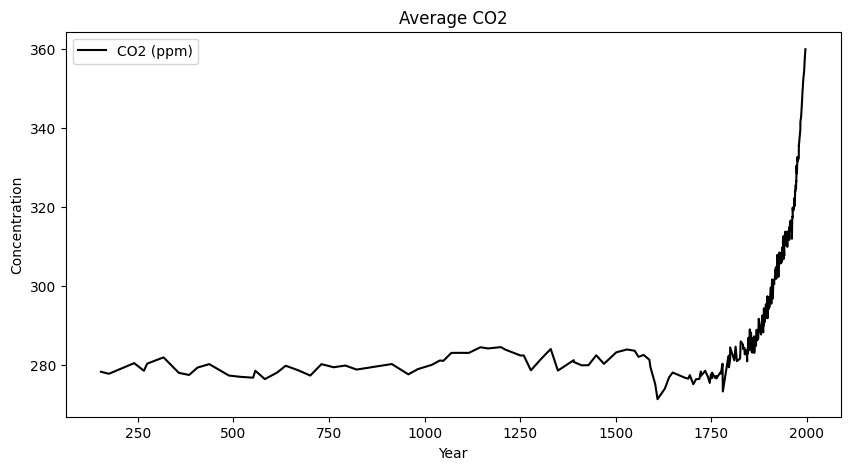

In [47]:
# create a figure and axis object to plot on.
fig, ax = plt.subplots(figsize=(10,5))

# we need to specify x-axis and y-axis data.
x_data = df_subset['age'] # isolate the year column from df_subset.
y_data = df_subset['conc'] # isolate the CO2 column from df_subset.

# now we can plot the data. THe argument order is x, then y.
plt.plot(x_data, y_data, color='black', label='CO2 (ppm)')
plt.legend() # displays labels you create for your plot lines

# add axis labels and a title.
plt.xlabel('Year')
plt.ylabel('Concentration')
plt.title('Average CO2')

# save figure
# look up how to save figures in matplotlib
plt.savefig("Average CO2")
plt.show('Average CO2')

This is good and well. However, we want to add information about the uncertainty in CO2 measurements. TO do so, we need the information in the uncertainty column.

Plot the same figure and add uncertainty bars for each measurement.

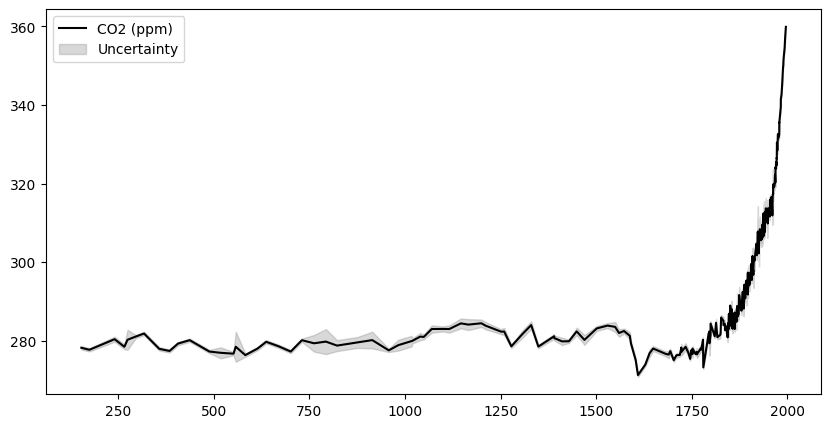

In [54]:
# Take 2 
fig, ax = plt.subplots(figsize=(10,5))

# you can use the same x_data and y_data as above, so long as you've run the earlier cell. Jupyter remembers var names.
# Manually create +/- uncertainty window
y_upper_uncert = y_data + df_subset['uncert'] # add uncertainty
y_lower_uncert = y_data - df_subset['uncert'] # subtract uncertainty

# plot data with uncertainty now.
plt.plot(x_data, y_data, color='black', label='CO2 (ppm)') # same as earlier

# This plot function creates a filled area between uncertainty bars.
# Figure out which uncertainties go where here.
plt.fill_between(
    x_data, y_upper_uncert, y_lower_uncert, color="gray", alpha=0.3, label="Uncertainty"
)

plt.legend()
plt.show()

# 4. Submit assignment.

Please submit your completed assignment to Brightspace this time.

# 4.5 Mini evaluations

1. Please rank from 1-5 how approachable this lab was for you. 5 = too easy, why did we even do this? 1 = too difficult, I felt very lost trying to complete this. 

2. Please write an additional 1-3 sentences explaining what did/not work well for you. 

Write your thoughts in the markdown cell below.

1. 5




2. This lab worked really well! It was pretty clear in the instructions what to do. Thank you :)